In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#En caso de no poder cargar el archivo con seaborns leerlo con pandas
df= pd.read_csv("Marketing_Limpio.csv")

In [3]:
df.shape

(18, 14)

In [4]:
df.head()

,Mes,Leads total,Ventas X Mes,Provisión,Reembolso,Reembolso marca,Bono a Marketing,Aportacion Agencia,Rembolso total,CAP GENERAL,CAP GAC,CAC GENERAL,CAC GAC,% DE RECUPERACIÓN DE MARCA
0,"Enero, 25",1042,26,346790.94,245306.88,211471.45,NaN,135319.49,211471.45,333,130,13338,5205,61.0
1,"Febrero, 25",561,20,423573.75,275727.55,228900.00,50000.0,144673.75,278900.00,755,258,21179,7234,66.0
2,"Marzo, 25",925,30,242750.78,156192.21,134648.46,50000.0,58102.32,184648.46,262,63,8092,1937,76.0
3,"Abril, 25",1083,30,517105.00,203631.27,245000.00,50000.0,222105.00,295000.00,477,205,17237,7404,57.0
4,"Mayo, 25",815,34,570803.67,417182.01,359639.66,50000.0,161164.01,409639.66,700,198,16788,4740,72.0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Mes                         18 non-null     str    
 1   Leads total                 18 non-null     int64  
 2   Ventas X Mes                18 non-null     int64  
 3   Provisión                   18 non-null     float64
 4   Reembolso                   6 non-null      float64
 5   Reembolso marca             17 non-null     float64
 6   Bono a Marketing            13 non-null     float64
 7   Aportacion Agencia          18 non-null     float64
 8   Rembolso total              17 non-null     float64
 9   CAP GENERAL                 18 non-null     int64  
 10  CAP GAC                     18 non-null     int64  
 11  CAC GENERAL                 18 non-null     int64  
 12  CAC GAC                     18 non-null     int64  
 13  % DE RECUPERACIÓN DE MARCA  18 non-null     floa

In [6]:
df.duplicated().sum()

np.int64(0)

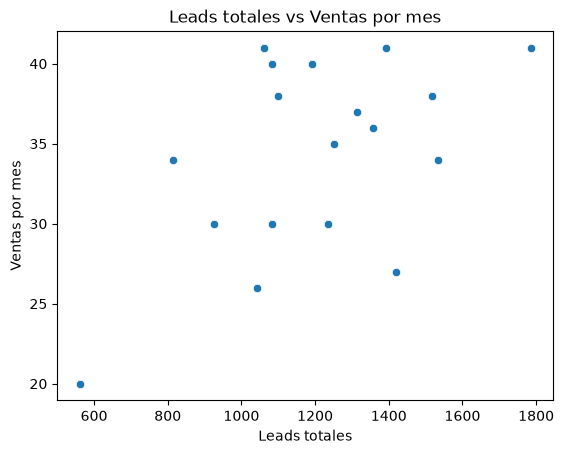

In [ ]:
sns.scatterplot(x="Leads total",y="Ventas X Mes",data=df)

plt.title("Leads totales vs Ventas por mes")
plt.xlabel("Leads totales")
plt.ylabel("Ventas por mes")
plt.show()

In [8]:
Vars_Indep = df[["Leads total"]]
Var_Dep = df["Ventas X Mes"]

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X=Vars_Indep,y=Var_Dep)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.01]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Leads total']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,21.06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [10]:
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'tol': 1e-06,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['Leads total'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([0.01102997]),
 'rank_': np.int64(1),
 'singular_': array([1180.89081253]),
 'intercept_': np.float64(21.055695505400244)}

ventas x mes = 21.0557 + 0.0110(Leads total)

In [11]:
model.score(Vars_Indep, Var_Dep)

0.273638241586587

In [20]:
y_pred = model.predict(Vars_Indep)
y_pred

array([32.54892862, 27.24351103, 31.25842164, 33.00115756, 30.04512448,
       33.00115756, 36.03440047, 36.70722889, 33.18866712, 34.20342475,
       32.75849813, 37.97567592, 37.77713639, 34.67771364, 40.74419945,
       36.42044956, 34.85419323, 35.56011157])

In [13]:
df["Predicciones"] = y_pred

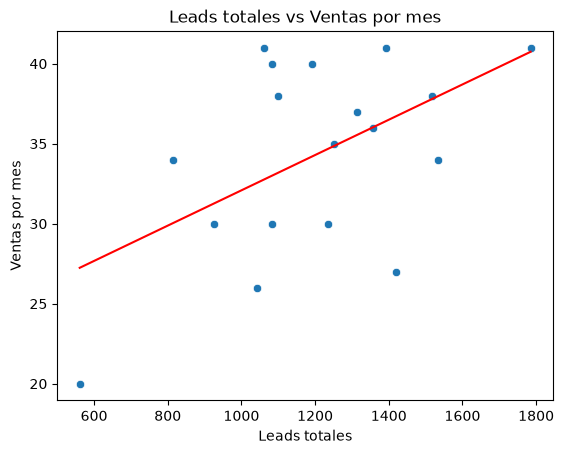

In [ ]:
# Gráfica con predicciones
sns.scatterplot( x="Leads total", y="Ventas X Mes",data=df)

sns.lineplot(x="Leads total",y="Predicciones",data=df,color="red")

plt.title("Leads totales vs Ventas por mes")
plt.xlabel("Leads totales")
plt.ylabel("Ventas por mes")
plt.show()

In [15]:
df_correlacion = df[["Leads total","Ventas X Mes","CAP GENERAL","CAC GENERAL"]]

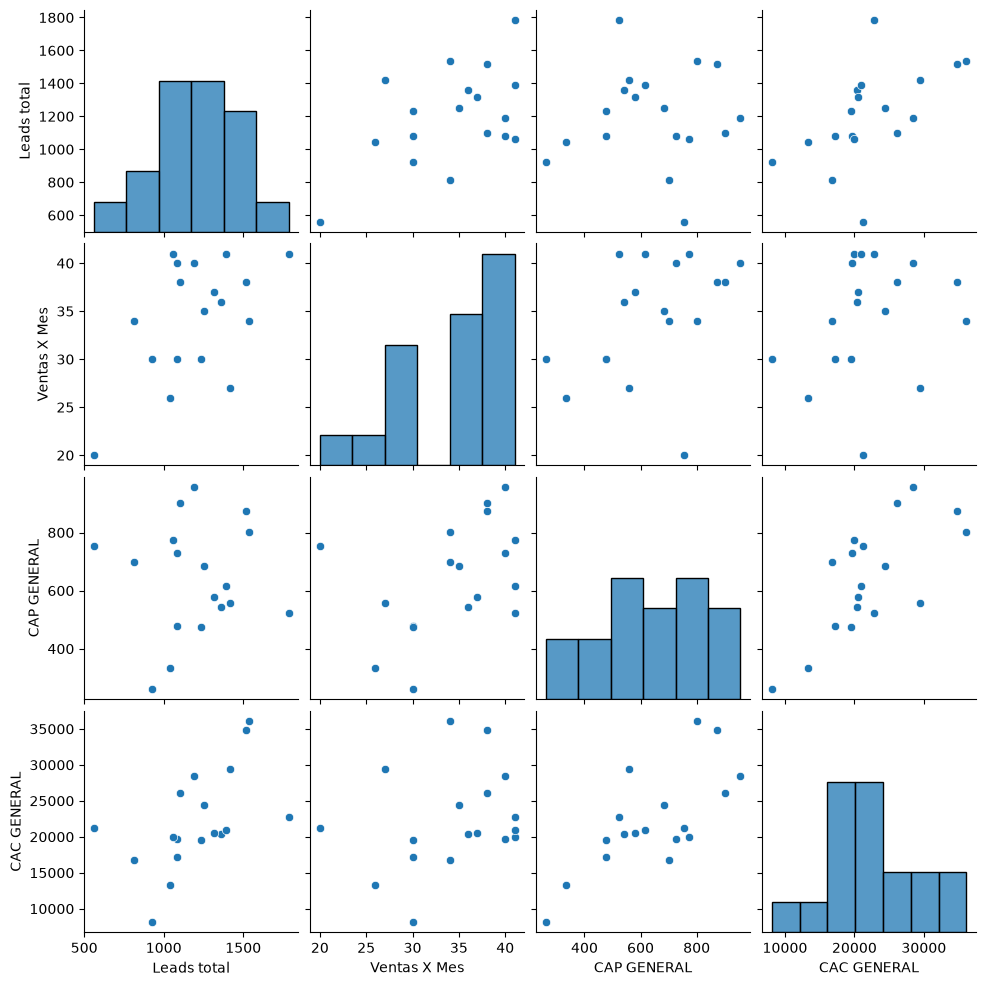

In [16]:
sns.pairplot(df_correlacion)
plt.show()

In [17]:
Corr_Factors = df_correlacion.corr()
Corr_Factors

,Leads total,Ventas X Mes,CAP GENERAL,CAC GENERAL
Leads total,1.000000,0.523104,0.030356,0.549786
Ventas X Mes,0.523104,1.000000,0.421516,0.258250
CAP GENERAL,0.030356,0.421516,1.000000,0.722404
CAC GENERAL,0.549786,0.258250,0.722404,1.000000


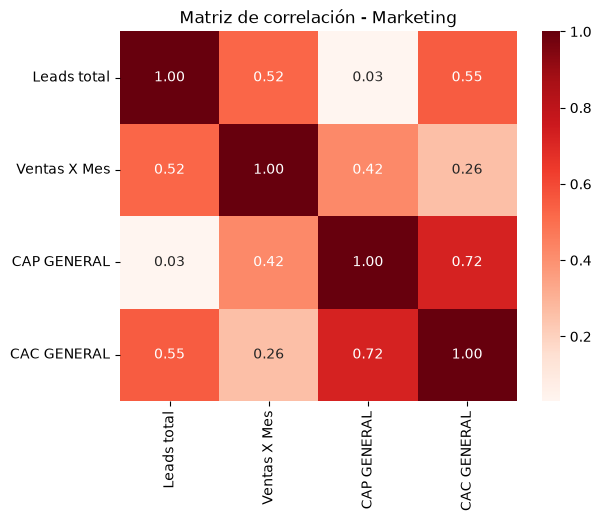

In [18]:
sns.heatmap(Corr_Factors,cmap="Reds",annot=True,fmt=".2f")

plt.title("Matriz de correlación - Marketing")
plt.show()